# Porównanie obu modeli

>>> NOTATNIK 05: PORÓWNANIE MODELI I ANALIZA WAŻNOŚCI CECH <<<
[*] Trenowanie modeli RF i XGB...

                       RANKING WAŻNOŚCI CECH (PROCENTOWY)                       
Cecha Sieciowa  Random Forest [%]  XGBoost [%]
     Dport_Num              38.47        12.14
 Bytes_per_Pkt              17.49         4.09
      TotBytes              17.31         4.95
           Dur               7.00         0.86
     Pkts_Freq               7.00         3.57
     State_Enc               3.44        18.04
     Proto_Enc               2.23         9.97
       DstPkts               2.00        12.27
       TotPkts               1.97         3.79
       SrcPkts               1.80        23.01
    Pkts_Ratio               1.29         7.31


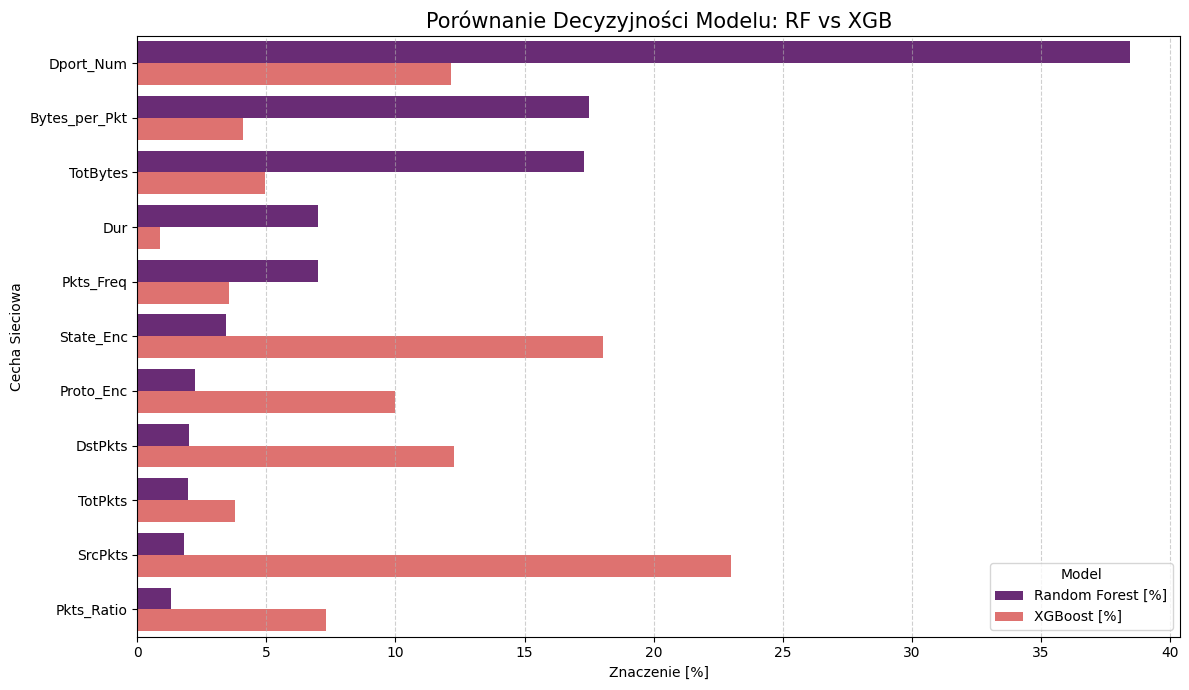


[*] Analiza odrzutów na danych testowych...


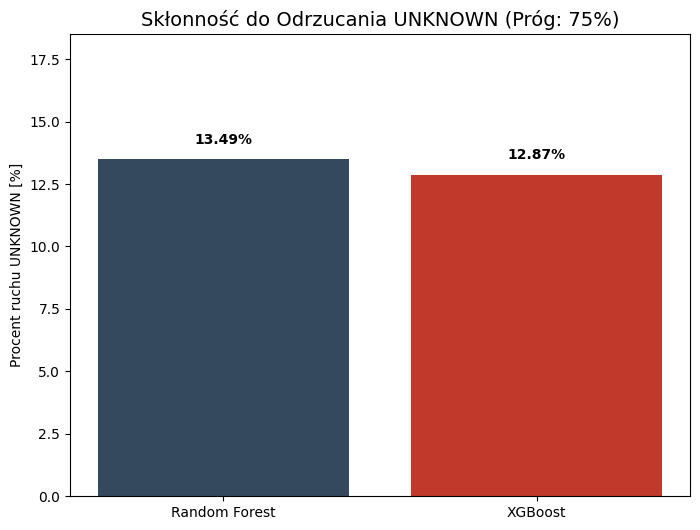

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import glob
import os

print("="*80)
print(">>> NOTATNIK 05: PORÓWNANIE MODELI I ANALIZA WAŻNOŚCI CECH <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. WCZYTANIE DANYCH
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ground_truth_final.csv')
df_train_raw = df_train_raw[df_train_raw['Refined_Label'] != 'Background Noise'].copy()

# 2. DEFINICJA CECH I INŻYNIERIA
RAW_NUM_COLS = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts']
for col in RAW_NUM_COLS:
    df_train_raw[col] = pd.to_numeric(df_train_raw[col], errors='coerce').fillna(0)

# Obliczamy cechy pochodne
df_train_raw['Bytes_per_Pkt'] = df_train_raw['TotBytes'] / (df_train_raw['TotPkts'] + 1e-6)
df_train_raw['Pkts_Freq']     = df_train_raw['TotPkts'] / (df_train_raw['Dur'] + 1e-6)
df_train_raw['Pkts_Ratio']    = df_train_raw['SrcPkts'] / (df_train_raw['DstPkts'] + 1e-6)

known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

df_train_raw['Proto_Enc'] = df_train_raw['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train_raw['State_Enc'] = df_train_raw['State'].apply(lambda x: safe_encode(x, known_states))
df_train_raw['Dport_Num'] = df_train_raw['Dport'].apply(safe_port)

FEATURES = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Proto_Enc', 'State_Enc', 'Dport_Num']
X_train = df_train_raw[FEATURES].fillna(0)

le_target = LabelEncoder()
y_train_rf = df_train_raw['Refined_Label']
y_train_xgb = le_target.fit_transform(df_train_raw['Refined_Label'])
weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

# 3. TRENING MODELI
print("[*] Trenowanie modeli RF i XGB...")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_rf)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_xgb, sample_weight=weights)

rf_imp_vals = rf.feature_importances_ * 100
xgb_imp_vals = xgb_model.feature_importances_ * 100

df_comparison_table = pd.DataFrame({
    'Cecha Sieciowa': FEATURES,
    'Random Forest [%]': rf_imp_vals,
    'XGBoost [%]': xgb_imp_vals
})

# Sortujemy po Random Forest dla czytelności
df_comparison_table = df_comparison_table.sort_values(by='Random Forest [%]', ascending=False)

print("\n" + "="*80)
print(f"{'RANKING WAŻNOŚCI CECH (PROCENTOWY)':^80}")
print("="*80)
print(df_comparison_table.to_string(index=False, float_format="%.2f"))
print("="*80)

# --- WYKRES 1: FEATURE IMPORTANCE ---
df_imp_plot = df_comparison_table.melt(id_vars='Cecha Sieciowa', var_name='Model', value_name='Znaczenie [%]')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_imp_plot, x='Znaczenie [%]', y='Cecha Sieciowa', hue='Model', palette='magma')
plt.title('Porównanie Decyzyjności Modelu: RF vs XGB', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '11_feature_importance_final.png'), dpi=300)
plt.show()

# --- WYKRES 2: ODRZUTY UNKNOWN ---
print("\n[*] Analiza odrzutów na danych testowych...")
test_files = glob.glob('../dane/testowe/*.csv')
df_test_raw = pd.concat([pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files], ignore_index=True)

for col in RAW_NUM_COLS:
    df_test_raw[col] = pd.to_numeric(df_test_raw.get(col, 0), errors='coerce').fillna(0)

df_test_raw['Bytes_per_Pkt'] = df_test_raw['TotBytes'] / (df_test_raw['TotPkts'] + 1e-6)
df_test_raw['Pkts_Freq']     = df_test_raw['TotPkts'] / (df_test_raw['Dur'] + 1e-6)
df_test_raw['Pkts_Ratio']    = df_test_raw['SrcPkts'] / (df_test_raw['DstPkts'] + 1e-6)
df_test_raw['Proto_Enc']     = df_test_raw['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_test_raw['State_Enc']     = df_test_raw['State'].apply(lambda x: safe_encode(x, known_states))
df_test_raw['Dport_Num']     = df_test_raw['Dport'].apply(safe_port)

X_new = df_test_raw[FEATURES].fillna(0)
THRESHOLD = 0.75

rf_unk = np.mean(np.max(rf.predict_proba(X_new), axis=1) < THRESHOLD) * 100
xgb_unk = np.mean(np.max(xgb_model.predict_proba(X_new), axis=1) < THRESHOLD) * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(['Random Forest', 'XGBoost'], [rf_unk, xgb_unk], color=['#34495e', '#c0392b'])
plt.title(f'Skłonność do Odrzucania UNKNOWN (Próg: {int(THRESHOLD*100)}%)', fontsize=14)
plt.ylabel('Procent ruchu UNKNOWN [%]')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(rf_unk, xgb_unk) + 5)
plt.savefig(os.path.join(output_dir, '12_unknown_rejection_final.png'), dpi=300)
plt.show()